# Fashion MNIST - CNN

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, InputLayer
print(f"Tesorflow version {tf.__version__}")

#read data with pandas
dataTrain = pd.read_csv('data/fashion-mnist_train.csv')
dataTest = pd.read_csv('data/fashion-mnist_test.csv')
#convert to numpy and initialize variables for training
X_train = dataTrain.iloc[:, 1:].to_numpy()
y_train = dataTrain.iloc[:, 0].to_numpy()
X_test = dataTest.iloc[:, 1:].to_numpy() 
y_test = dataTest.iloc[:, 0].to_numpy()
# reshape for convnet
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print(X_train.shape)
print(X_test.shape)


Tesorflow version 2.19.0
(60000, 28, 28, 1)
(10000, 28, 28, 1)


## A first CNN

In [25]:
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten
from keras.regularizers import l2

model = Sequential()
model.add(InputLayer((28, 28, 1)))
model.add(Conv2D(10, kernel_size=(3, 3), activation="sigmoid"))
model.add(Flatten())
model.add(Dense(10, activation="softmax"))

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 26, 26, 10)          │             100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_12 (Flatten)                 │ (None, 6760)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 10)                  │          67,610 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,710 (264.49 KB)

 Trainable params: 67,710 (264.49 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(
    X_train, 
    y_train,
    validation_data=(X_test, y_test),
    epochs=10, 
    batch_size=1000)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5687 - loss: 1.3303 - val_accuracy: 0.8259 - val_loss: 0.4963
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8333 - loss: 0.4690 - val_accuracy: 0.8573 - val_loss: 0.4092
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8631 - loss: 0.3892 - val_accuracy: 0.8648 - val_loss: 0.3879
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8747 - loss: 0.3591 - val_accuracy: 0.8733 - val_loss: 0.3605
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8836 - loss: 0.3334 - val_accuracy: 0.8796 - val_loss: 0.3422
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8928 - loss: 0.3088 - val_accuracy: 0.8801 - val_loss: 0.3402
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8933 - loss: 0.3038 - val_accuracy: 0.8907 - val_loss: 0.3207
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8982 - loss: 0.2852 - val_accuracy: 0.8924 - v

## Lets look into the output of the first layer 

To do that, we create a new model where we just add the first trained layer.

In [28]:
truncatedModel = Sequential(model.layers[0:1])
truncatedModel.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 26, 26, 10)          │             100 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 100 (400.00 B)

 Trainable params: 100 (400.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
result = truncatedModel.predict(X_test[0:8])
result.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


(8, 26, 26, 10)

Visualize the output of the first layer

Input was


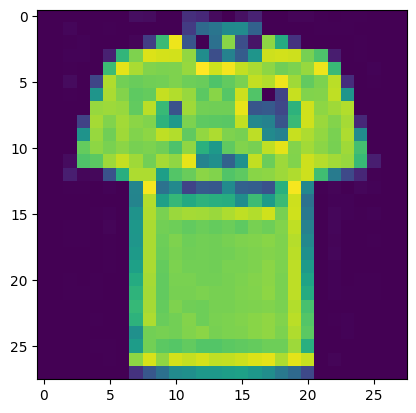

Output of layer is 10 Channels:


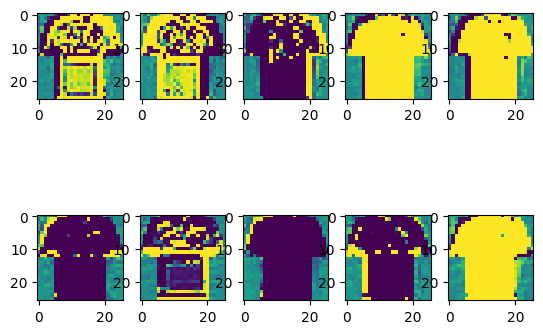

In [30]:
sampleIdx=0 
print("Input was")
plt.imshow(X_test[sampleIdx].reshape(28,28))
plt.show()

print("Output of layer is 10 Channels:")
fig, axs = plt.subplots(2,5)
axs = axs.reshape(-1,)
for index in range(10):
    axs[index].imshow(result[sampleIdx][:, :, index])


## Exercise

1) Now try to improve the model to get better accuaracy. Rates above 95 should be possible. 

2) Draw Learning curves while training

## Solution

In [61]:
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Conv2D, Flatten
from keras.regularizers import l2

model = Sequential()
model.add(InputLayer((28, 28, 1)))
model.add(Conv2D(80, kernel_size=(3, 3), strides=(2,2), activation="relu"))
model.add(Conv2D(40, kernel_size=(3, 3), strides=(2,2), activation="relu"))
model.add(Flatten())
model.add(Dense(10, kernel_regularizer=l2(0.2), activation="softmax"))

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()
model.fit(
    X_train, 
    y_train,
    validation_data=(X_test, y_test),
    epochs=100, 
    batch_size=1000)

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_87 (Conv2D)                   │ (None, 13, 13, 80)          │             800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_88 (Conv2D)                   │ (None, 6, 6, 40)            │          28,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_36 (Flatten)                 │ (None, 1440)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 10)                  │          14,410 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,050 (172.07 KB)

 Trainable params: 44,050 (172.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.5475 - loss: 6.4964 - val_accuracy: 0.8014 - val_loss: 2.3038
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8183 - loss: 2.0447 - val_accuracy: 0.8505 - val_loss: 1.4901
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8557 - loss: 1.3744 - val_accuracy: 0.8643 - val_loss: 1.1155
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8711 - loss: 1.0294 - val_accuracy: 0.8757 - val_loss: 0.8610
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8757 - loss: 0.8255 - val_accuracy: 0.8813 - val_loss: 0.7037
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8871 - loss: 0.6648 - val_accuracy: 0.8850 - val_loss: 0.6049
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8921 - loss: 0.5664 - val_accuracy: 0.8833 - val_loss: 0.5414
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8923 - loss: 0.4997 - val_accuracy: 0.